## **Assignment Supervised machine Learning - Regression**

### **_House Price Prediction Using Bolton Housing Data_**
This dataset provides information about house prices in Bolton. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "Boston Housing Dataset" from sklearn. The regression model will either be a Decision Tree or Random Forest regressor.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (Bolton Housing):

* CRIM: Crime rate by town
* ZN: Proportion of residential land zoned for large lots
* INDUS: Proportion of non-retail business acres per town
* CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX: Nitric oxide concentration (parts per 10 million)
* RM: Average number of rooms per dwelling
* AGE: Proportion of owner-occupied units built before 1940
* DIS: Weighted distances to five Boston employment centers
* RAD: Index of accessibility to radial highways
* TAX: Full-value property tax rate per `$10,000`
* PTRATIO: Pupil-teacher ratio by town
* B: Proportion of Black population
* LSTAT: Percentage of lower status of the population
* MEDV (Target): Median value of owner-occupied homes in `$1,000s`



**Dataset is from sklearn Datasets**

First 5 rows of the dataset:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Target
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  Target   506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB

Summary Statistics:


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,Target
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000



Missing Values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
Target     0
dtype: int64


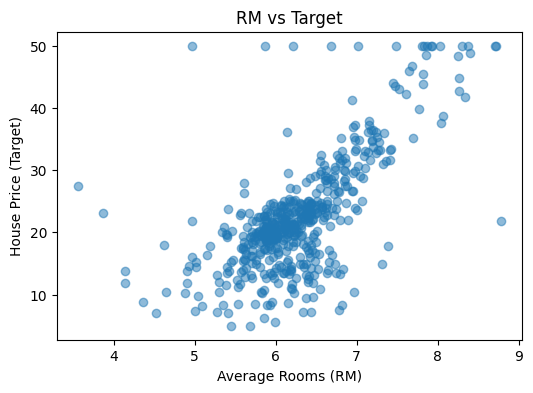

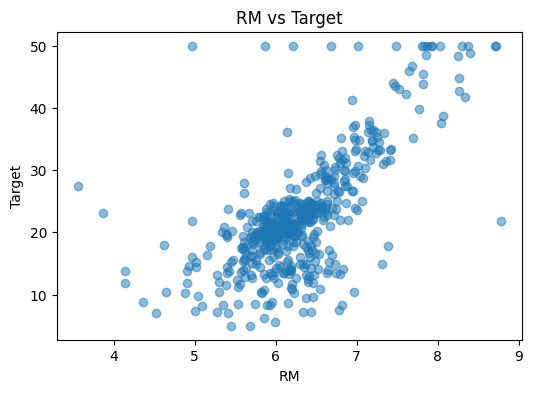

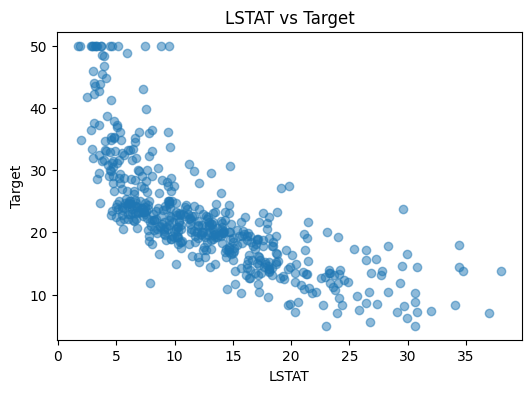

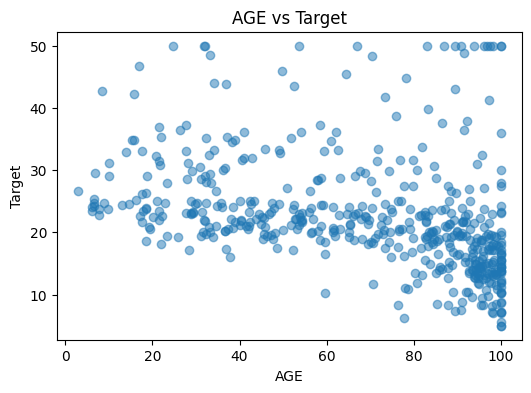

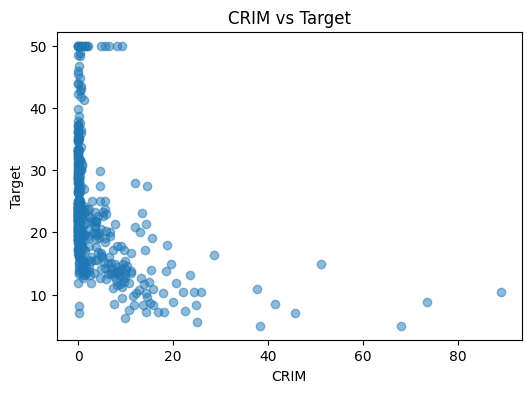


Model Evaluation:
RMSE: 2.8109631609391226
R-squared: 0.8922527442109116

Best Parameters: {'max_depth': 10, 'n_estimators': 50}

Tuned Model Evaluation:
Tuned RMSE: 2.724436890396961
Tuned R-squared: 0.8987839430903407

Predicted House Price: 21.82389199828796


In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# --- Data Collection and Loading ---
# Load Boston Housing dataset from OpenML (safe replacement for deprecated load_boston)
boston = fetch_openml(name="boston", version=1, as_frame=True)

# Convert to DataFrame
df = boston.frame

# Rename target column for clarity
df.rename(columns={"MEDV": "Target"}, inplace=True)


# --- Quick Check of Data ---
print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
display(df.describe())


# --- EDA and Data Preprocessing ---
print("\nMissing Values:")
print(df.isnull().sum())

# Simple scatter plot example
plt.figure(figsize=(6,4))
plt.scatter(df['RM'], df['Target'], alpha=0.5)
plt.xlabel('Average Rooms (RM)')
plt.ylabel('House Price (Target)')
plt.title('RM vs Target')
plt.show()


# Function to automate scatter plots
def plot_feature_vs_target(df, features, target='Target'):
    for feature in features:
        plt.figure(figsize=(6,4))
        plt.scatter(df[feature], df[target], alpha=0.5)
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f'{feature} vs {target}')
        plt.show()


# Use the function for selected features
features_to_plot = ['RM', 'LSTAT', 'AGE', 'CRIM']
plot_feature_vs_target(df, features_to_plot)


# --- ML Model Training ---
# Define features (X) and target (y)
X = df.drop('Target', axis=1)
y = df['Target']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Choose a regression model (Random Forest performs better)
model = RandomForestRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)


# --- Model Evaluation ---
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("RMSE:", rmse)
print("R-squared:", r2)


# --- Parameter Tuning (Grid Search) ---
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

best_model = grid.best_estimator_


# --- Evaluate Tuned Model ---
y_pred_best = best_model.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("\nTuned Model Evaluation:")
print("Tuned RMSE:", rmse_best)
print("Tuned R-squared:", r2_best)


# --- Model Prediction ---
# Example new input
new_data = pd.DataFrame([{
    'CRIM': 0.2,
    'ZN': 12.5,
    'INDUS': 7.07,
    'CHAS': 0,
    'NOX': 0.5,
    'RM': 6.5,
    'AGE': 68,
    'DIS': 4.0,
    'RAD': 2,
    'TAX': 250,
    'PTRATIO': 17,
    'B': 400,
    'LSTAT': 12
}])

prediction = best_model.predict(new_data)

print("\nPredicted House Price:", prediction[0])